In [3]:
# Python code to run in Jupyter.
# Purpose: take an input image, automatically extract the main object (remove background and noise),
# resize to a requested output width (keeping aspect ratio), convert to a 1-bit bitmap and pack into bytes,
# produce a C-style PROGMEM array (static const unsigned char PROGMEM name[] = {...};)
# and create a verification image rendered from that PROGMEM array.
#
# The script saves the .c file and verification PNG under ./results relative to the current directory.
#
# Usage examples at the bottom process all images under ./imgs.
# You can call process_image("/path/to/your.png", desired_width, "array_name", threshold=100, fill_object=True)
#
# Note: This code prefers OpenCV (cv2) if available, and falls back to PIL+numpy-based methods otherwise.

from PIL import Image, ImageOps, ImageFilter
import numpy as np
import os
import textwrap
import math
import matplotlib.pyplot as plt

# Try importing cv2; if not available, we'll fall back to pure PIL/numpy routines
try:
    import cv2
    HAVE_CV2 = True
except Exception as e:
    print("OpenCV (cv2) not available, falling back to PIL-based processing.")
    HAVE_CV2 = False

OpenCV (cv2) not available, falling back to PIL-based processing.


In [4]:
# Helper functions for image processing
OUTPUT_DIR = "./results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def ensure_gray_alpha(img_pil):
    """
    Extract grayscale and alpha channels from PIL image.
    Returns (gray, alpha) as numpy arrays.
    """
    if img_pil.mode == "RGBA":
        alpha = np.array(img_pil.split()[3])
    else:
        alpha = np.ones((img_pil.height, img_pil.width), dtype=np.uint8) * 255
    
    gray = np.array(img_pil.convert("L"))
    return gray, alpha

def denoise_mask(mask):
    """Remove noise from mask using morphological operations."""
    if HAVE_CV2:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=1)
    else:
        # Fallback: use PIL median filter
        pil_mask = Image.fromarray(mask)
        pil_mask = pil_mask.filter(ImageFilter.MedianFilter(size=3))
        mask = np.array(pil_mask)
    return mask

def largest_contour_mask(mask, fill_object=True):
    """
    Keep only the largest connected component and optionally fill holes.
    """
    if HAVE_CV2:
        contours, hierarchy = cv2.findContours(mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            largest = max(contours, key=cv2.contourArea)
            mask = np.zeros_like(mask)
            cv2.drawContours(mask, [largest], 0, 255, -1)
            
            if fill_object:
                # Fill holes inside the object
                mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, 
                                       cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5)))
    else:
        # Fallback: simple binarization
        mask = (mask > 127).astype(np.uint8) * 255
    return mask

def pack_bits_row_major(bin_fore):
    """
    Pack binary foreground array into bytes (row-major).
    Returns (packed_bytes, width, height, bytes_per_row).
    """
    height, width = bin_fore.shape
    bytes_per_row = (width + 7) // 8
    packed_bytes = bytearray()
    
    for row in range(height):
        for byte_idx in range(bytes_per_row):
            byte_val = 0
            for bit_idx in range(8):
                pixel_idx = byte_idx * 8 + bit_idx
                if pixel_idx < width:
                    if bin_fore[row, pixel_idx] > 0:
                        byte_val |= (1 << (7 - bit_idx))
            packed_bytes.append(byte_val)
    
    return bytes(packed_bytes), width, height, bytes_per_row

def format_c_array(packed_bytes, array_name, width, height, bytes_per_row):
    """Format packed bytes as C PROGMEM array."""
    lines = []
    lines.append(f"static const unsigned char PROGMEM {array_name}[] = {{")
    
    hex_strs = [f"0x{b:02x}" for b in packed_bytes]
    for i in range(0, len(hex_strs), 12):
        chunk = hex_strs[i:i+12]
        line = "  " + ", ".join(chunk)
        if i + 12 < len(hex_strs):
            line += ","
        lines.append(line)
    
    lines.append("};")
    lines.append("")
    lines.append(f"// Width: {width}, Height: {height}, Bytes per row: {bytes_per_row}")
    
    return "\n".join(lines)

def reconstruct_image_from_bytes(packed_bytes, width, height, bytes_per_row):
    """Reconstruct image from packed bytes for verification."""
    img_array = np.zeros((height, width), dtype=np.uint8)
    
    for row in range(height):
        for byte_idx in range(bytes_per_row):
            byte_val = packed_bytes[row * bytes_per_row + byte_idx]
            for bit_idx in range(8):
                pixel_idx = byte_idx * 8 + bit_idx
                if pixel_idx < width:
                    if byte_val & (1 << (7 - bit_idx)):
                        img_array[row, pixel_idx] = 255
    
    return img_array

In [5]:
def process_image(path, out_width, array_name="sprite", save_prefix=None, debug_show=True, threshold=100, fill_object=True):
    """
    path: path to input image
    out_width: desired output width in pixels (for final 1-bit sprite)
    array_name: C identifier for the generated array
    save_prefix: if provided, files saved as {save_prefix}_progmeme.c
    debug_show: whether to display reconstructed PROGMEM bitmap inline
    threshold: grayscale threshold (default 100)
        - Positive: keep pixels > threshold (e.g., 100 keeps pixels > 100)
        - Negative: keep pixels < abs(threshold) (e.g., -100 keeps pixels < 100)
    fill_object: if True, fill interior holes in the object mask; if False, preserve holes
    """
    print(f"Processing: {path} -> target width {out_width} px, array name '{array_name}'")
    img_pil = Image.open(path).convert("RGBA")
    gray, alpha = ensure_gray_alpha(img_pil)
    h0, w0 = gray.shape

    # Build initial mask:
    # If image has transparent pixels (alpha less than 255), use that
    if alpha.max() < 255:
        mask = (alpha > (alpha.max() // 2)).astype(np.uint8) * 255
        print("Using alpha channel as mask (transparency detected).")
    else:
        # Use fixed grayscale threshold to separate foreground from background.
        # Positive threshold: keep pixels > threshold
        # Negative threshold: keep pixels < abs(threshold)
        if threshold >= 0:
            threshold = int(np.clip(threshold, 0, 255))
            th = (gray > threshold).astype(np.uint8) * 255
            print(f"Using grayscale threshold: > {threshold}")
        else:
            threshold = -int(np.clip(-threshold, 0, 255))
            th = (gray < -threshold).astype(np.uint8) * 255
            print(f"Using grayscale threshold: < {-threshold}")
        
        # Heuristic: figure out if background is white or black by sampling corners
        corners = np.array([gray[0, 0], gray[0, -1], gray[-1, 0], gray[-1, -1]])
        bg_is_dark = corners.mean() < 127
        if bg_is_dark:
            # if background is dark, we want object to be brighter than background
            mask = th.copy()
        else:
            # if background is light, invert threshold output so foreground is white
            mask = (255 - th)

    mask = denoise_mask(mask.astype(np.uint8))

    # Keep only the largest connected component (assume that's the object),
    # and optionally fill interior holes based on fill_object flag.
    mask = largest_contour_mask(mask, fill_object=fill_object)

    # If mask is empty, try alternate thresholding strategy
    if mask.sum() == 0:
        print("Warning: mask empty. Trying inverted threshold fallback.")
        mask = 255 - mask
        mask = largest_contour_mask(mask, fill_object=fill_object)

    # Crop to bounding rect
    ys, xs = np.where(mask > 0)
    if len(xs) == 0 or len(ys) == 0:
        raise RuntimeError("Could not find any object in the image to extract.")
    x_min, x_max = xs.min(), xs.max()
    y_min, y_max = ys.min(), ys.max()
    crop_w = x_max - x_min + 1
    crop_h = y_max - y_min + 1
    cropped_img = img_pil.crop((x_min, y_min, x_max + 1, y_max + 1))
    cropped_mask = mask[y_min:y_max + 1, x_min:x_max + 1]

    # Compute output height from aspect ratio
    out_height = max(1, int(round(out_width * (crop_h / crop_w))))
    print(f"Detected object box: {crop_w}x{crop_h} -> resized to {out_width}x{out_height}")

    # Resize mask to desired size using nearest to keep crisp edges
    if HAVE_CV2:
        resized_mask = cv2.resize(cropped_mask, (out_width, out_height), interpolation=cv2.INTER_NEAREST)
    else:
        resized_mask = np.array(cropped_img.convert("L").resize((out_width, out_height), resample=Image.NEAREST))
        # use threshold to binarize
        resized_mask = (resized_mask > 127).astype(np.uint8) * 255

    # Convert to boolean foreground (1) / background (0)
    bin_fore = (resized_mask > 0).astype(np.uint8)
    packed_bytes, width, height, bytes_per_row = pack_bits_row_major(bin_fore)
    c_code = format_c_array(packed_bytes, array_name, width, height, bytes_per_row)

    # Save C file
    if save_prefix is None:
        base = array_name
    else:
        base = save_prefix
    c_path = os.path.join(OUTPUT_DIR, f"{base}_progmeme.c")
    with open(c_path, "w") as f:
        f.write(c_code)

    # Reconstruct image for display
    recon_arr = reconstruct_image_from_bytes(packed_bytes, width, height, bytes_per_row)
    recon_pil = Image.fromarray(recon_arr).convert("L")
    
    print(f"Saved C array to: {c_path}")

    # Display the reconstructed PROGMEM bitmap
    if debug_show:
        fig, ax = plt.subplots(1, 1, figsize=(6, 6))
        ax.imshow(recon_pil, cmap="gray", vmin=0, vmax=255)
        ax.set_title(f"PROGMEM Reconstruction: {array_name} ({width}x{height})")
        ax.axis("off")
        plt.tight_layout()
        plt.show()

    # Print a short preview of the C array
    print("\n--- C array preview ---\n")
    preview_lines = c_code.splitlines()[:40]
    print("\n".join(preview_lines))
    print("\n--- end preview ---\n")

    return {
        "c_path": c_path,
        "c_code": c_code,
        "width": width,
        "height": height,
        "bytes_per_row": bytes_per_row,
    }

Processing: imgs/cloud_1.jpg -> target width 30 px, array name 'cloud_1'
Using grayscale threshold: < 100
Detected object box: 194x109 -> resized to 30x17
Saved C array to: ./results/cloud_1_progmeme.c


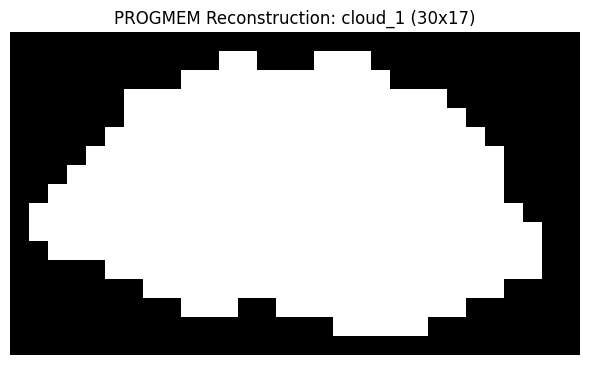


--- C array preview ---

static const unsigned char PROGMEM cloud_1[] = {
  0x00, 0x00, 0x00, 0x00, 0x00, 0x18, 0xe0, 0x00, 0x00, 0x7f, 0xf0, 0x00,
  0x03, 0xff, 0xfe, 0x00, 0x03, 0xff, 0xff, 0x00, 0x07, 0xff, 0xff, 0x80,
  0x0f, 0xff, 0xff, 0xc0, 0x1f, 0xff, 0xff, 0xc0, 0x3f, 0xff, 0xff, 0xc0,
  0x7f, 0xff, 0xff, 0xe0, 0x7f, 0xff, 0xff, 0xf0, 0x3f, 0xff, 0xff, 0xf0,
  0x07, 0xff, 0xff, 0xf0, 0x01, 0xff, 0xff, 0xc0, 0x00, 0x73, 0xff, 0x00,
  0x00, 0x00, 0x7c, 0x00, 0x00, 0x00, 0x00, 0x00
};

// Width: 30, Height: 17, Bytes per row: 4

--- end preview ---

Processing: imgs/cloud_2.jpg -> target width 45 px, array name 'cloud_2'
Using grayscale threshold: < 100
Detected object box: 286x153 -> resized to 45x24
Saved C array to: ./results/cloud_2_progmeme.c


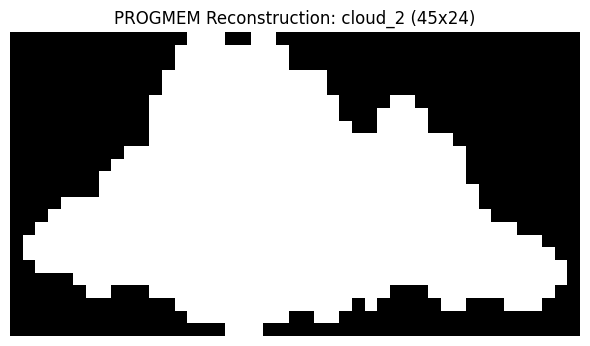


--- C array preview ---

static const unsigned char PROGMEM cloud_2[] = {
  0x00, 0x03, 0x98, 0x00, 0x00, 0x00, 0x00, 0x07, 0xfc, 0x00, 0x00, 0x00,
  0x00, 0x07, 0xfc, 0x00, 0x00, 0x00, 0x00, 0x0f, 0xff, 0x80, 0x00, 0x00,
  0x00, 0x0f, 0xff, 0x80, 0x00, 0x00, 0x00, 0x1f, 0xff, 0xc3, 0x00, 0x00,
  0x00, 0x1f, 0xff, 0xc7, 0x80, 0x00, 0x00, 0x1f, 0xff, 0xe7, 0x80, 0x00,
  0x00, 0x1f, 0xff, 0xff, 0xe0, 0x00, 0x00, 0x7f, 0xff, 0xff, 0xf0, 0x00,
  0x00, 0xff, 0xff, 0xff, 0xf0, 0x00, 0x01, 0xff, 0xff, 0xff, 0xf0, 0x00,
  0x01, 0xff, 0xff, 0xff, 0xf8, 0x00, 0x0f, 0xff, 0xff, 0xff, 0xf8, 0x00,
  0x1f, 0xff, 0xff, 0xff, 0xfc, 0x00, 0x3f, 0xff, 0xff, 0xff, 0xff, 0x00,
  0x7f, 0xff, 0xff, 0xff, 0xff, 0xc0, 0x7f, 0xff, 0xff, 0xff, 0xff, 0xe0,
  0x3f, 0xff, 0xff, 0xff, 0xff, 0xf0, 0x07, 0xff, 0xff, 0xff, 0xff, 0xf0,
  0x03, 0x1f, 0xff, 0xfc, 0x7f, 0xe0, 0x00, 0x07, 0xff, 0xe8, 0x31, 0xc0,
  0x00, 0x03, 0xfc, 0xc0, 0x00, 0x00, 0x00, 0x00, 0x70, 0x00, 0x00, 0x00
};

// Width: 45, Height: 24, Bytes pe

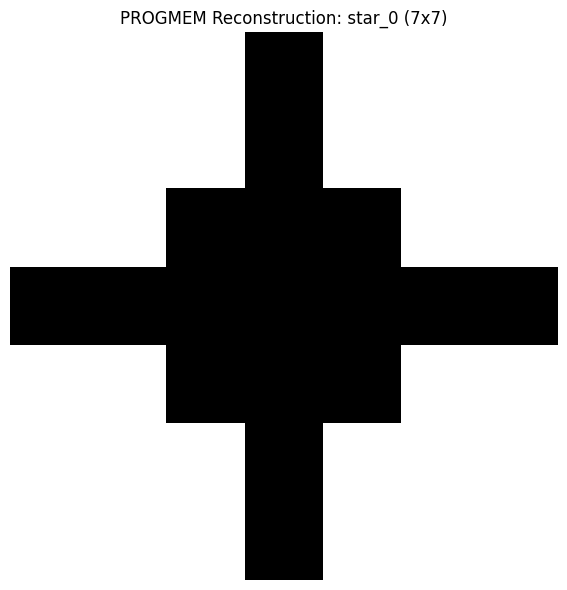


--- C array preview ---

static const unsigned char PROGMEM star_0[] = {
  0xee, 0xee, 0xc6, 0x00, 0xc6, 0xee, 0xee
};

// Width: 7, Height: 7, Bytes per row: 1

--- end preview ---

Processing: imgs/star_1.jpg -> target width 11 px, array name 'star_1'
Using grayscale threshold: > 80
Detected object box: 189x187 -> resized to 11x11
Saved C array to: ./results/star_1_progmeme.c


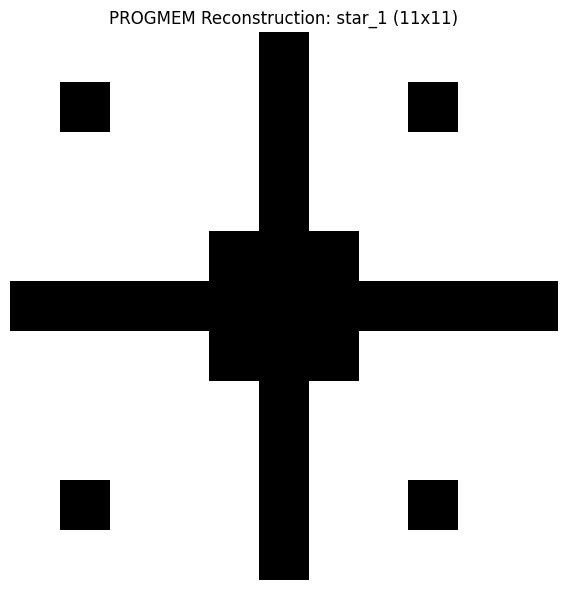


--- C array preview ---

static const unsigned char PROGMEM star_1[] = {
  0xfb, 0xe0, 0xbb, 0x60, 0xfb, 0xe0, 0xfb, 0xe0, 0xf1, 0xe0, 0x00, 0x00,
  0xf1, 0xe0, 0xfb, 0xe0, 0xfb, 0xe0, 0xbb, 0x60, 0xfb, 0xe0
};

// Width: 11, Height: 11, Bytes per row: 2

--- end preview ---

Processing: imgs/sun.jpg -> target width 50 px, array name 'sun'
Using grayscale threshold: > 100
Detected object box: 560x558 -> resized to 50x50
Saved C array to: ./results/sun_progmeme.c


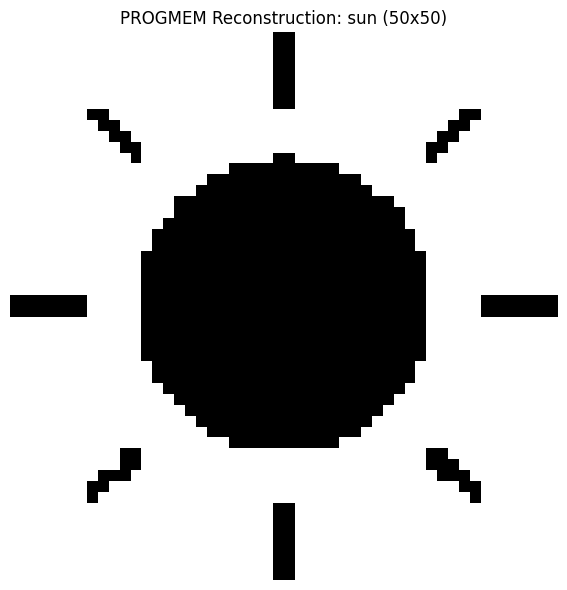


--- C array preview ---

static const unsigned char PROGMEM sun[] = {
  0xff, 0xff, 0xff, 0x3f, 0xff, 0xff, 0xc0, 0xff, 0xff, 0xff, 0x3f, 0xff,
  0xff, 0xc0, 0xff, 0xff, 0xff, 0x3f, 0xff, 0xff, 0xc0, 0xff, 0xff, 0xff,
  0x3f, 0xff, 0xff, 0xc0, 0xff, 0xff, 0xff, 0x3f, 0xff, 0xff, 0xc0, 0xff,
  0xff, 0xff, 0x3f, 0xff, 0xff, 0xc0, 0xff, 0xff, 0xff, 0x3f, 0xff, 0xff,
  0xc0, 0xfe, 0x7f, 0xff, 0xff, 0xff, 0x9f, 0xc0, 0xff, 0x3f, 0xff, 0xff,
  0xff, 0x3f, 0xc0, 0xff, 0x9f, 0xff, 0xff, 0xfe, 0x7f, 0xc0, 0xff, 0xcf,
  0xff, 0xff, 0xfc, 0xff, 0xc0, 0xff, 0xef, 0xff, 0x3f, 0xfd, 0xff, 0xc0,
  0xff, 0xff, 0xf0, 0x03, 0xff, 0xff, 0xc0, 0xff, 0xff, 0xc0, 0x00, 0xff,
  0xff, 0xc0, 0xff, 0xff, 0x80, 0x00, 0x7f, 0xff, 0xc0, 0xff, 0xfe, 0x00,
  0x00, 0x1f, 0xff, 0xc0, 0xff, 0xfe, 0x00, 0x00, 0x0f, 0xff, 0xc0, 0xff,
  0xfc, 0x00, 0x00, 0x0f, 0xff, 0xc0, 0xff, 0xf8, 0x00, 0x00, 0x07, 0xff,
  0xc0, 0xff, 0xf8, 0x00, 0x00, 0x07, 0xff, 0xc0, 0xff, 0xf0, 0x00, 0x00,
  0x03, 0xff, 0xc0, 0xff, 0xf0, 0x00, 0x0

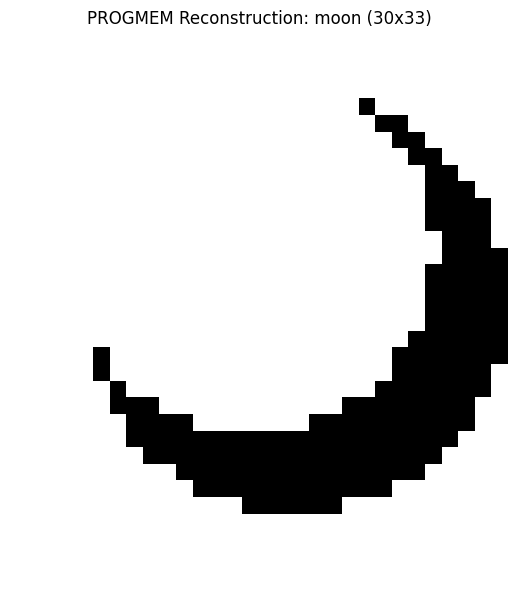


--- C array preview ---

static const unsigned char PROGMEM moon[] = {
  0xff, 0xff, 0xff, 0xfc, 0xff, 0xff, 0xff, 0xfc, 0xff, 0xff, 0xff, 0xfc,
  0xff, 0xff, 0xff, 0xfc, 0xff, 0xff, 0xfb, 0xfc, 0xff, 0xff, 0xfc, 0xfc,
  0xff, 0xff, 0xfe, 0x7c, 0xff, 0xff, 0xff, 0x3c, 0xff, 0xff, 0xff, 0x9c,
  0xff, 0xff, 0xff, 0x8c, 0xff, 0xff, 0xff, 0x84, 0xff, 0xff, 0xff, 0x84,
  0xff, 0xff, 0xff, 0xc4, 0xff, 0xff, 0xff, 0xc0, 0xff, 0xff, 0xff, 0x80,
  0xff, 0xff, 0xff, 0x80, 0xff, 0xff, 0xff, 0x80, 0xff, 0xff, 0xff, 0x80,
  0xff, 0xff, 0xff, 0x00, 0xfb, 0xff, 0xfe, 0x00, 0xfb, 0xff, 0xfe, 0x04,
  0xfd, 0xff, 0xfc, 0x04, 0xfc, 0x7f, 0xf0, 0x0c, 0xfe, 0x1f, 0xc0, 0x0c,
  0xfe, 0x00, 0x00, 0x1c, 0xff, 0x00, 0x00, 0x3c, 0xff, 0xc0, 0x00, 0x7c,
  0xff, 0xe0, 0x01, 0xfc, 0xff, 0xfc, 0x0f, 0xfc, 0xff, 0xff, 0xff, 0xfc,
  0xff, 0xff, 0xff, 0xfc, 0xff, 0xff, 0xff, 0xfc, 0xff, 0xff, 0xff, 0xfc
};

// Width: 30, Height: 33, Bytes per row: 4

--- end preview ---

Processing: imgs/cactus_1.jpg -> target width 

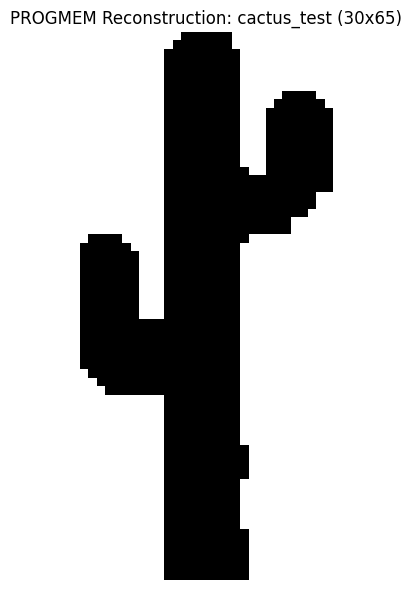


--- C array preview ---

static const unsigned char PROGMEM cactus_test[] = {
  0xff, 0xf0, 0x3f, 0xfc, 0xff, 0xe0, 0x3f, 0xfc, 0xff, 0xc0, 0x1f, 0xfc,
  0xff, 0xc0, 0x1f, 0xfc, 0xff, 0xc0, 0x1f, 0xfc, 0xff, 0xc0, 0x1f, 0xfc,
  0xff, 0xc0, 0x1f, 0xfc, 0xff, 0xc0, 0x1f, 0x0c, 0xff, 0xc0, 0x1e, 0x04,
  0xff, 0xc0, 0x1c, 0x00, 0xff, 0xc0, 0x1c, 0x00, 0xff, 0xc0, 0x1c, 0x00,
  0xff, 0xc0, 0x1c, 0x00, 0xff, 0xc0, 0x1c, 0x00, 0xff, 0xc0, 0x1c, 0x00,
  0xff, 0xc0, 0x1c, 0x00, 0xff, 0xc0, 0x0c, 0x00, 0xff, 0xc0, 0x00, 0x00,
  0xff, 0xc0, 0x00, 0x00, 0xff, 0xc0, 0x00, 0x0c, 0xff, 0xc0, 0x00, 0x0c,
  0xff, 0xc0, 0x00, 0x1c, 0xff, 0xc0, 0x00, 0x7c, 0xff, 0xc0, 0x00, 0x7c,
  0x87, 0xc0, 0x0f, 0xfc, 0x03, 0xc0, 0x1f, 0xfc, 0x01, 0xc0, 0x1f, 0xfc,
  0x01, 0xc0, 0x1f, 0xfc, 0x01, 0xc0, 0x1f, 0xfc, 0x01, 0xc0, 0x1f, 0xfc,
  0x01, 0xc0, 0x1f, 0xfc, 0x01, 0xc0, 0x1f, 0xfc, 0x01, 0xc0, 0x1f, 0xfc,
  0x01, 0xc0, 0x1f, 0xfc, 0x00, 0x00, 0x1f, 0xfc, 0x00, 0x00, 0x1f, 0xfc,
  0x00, 0x00, 0x1f, 0xfc, 0x00, 0

In [12]:
examples = [
    ("imgs/cloud_1.jpg", 30, "cloud_1", -100),
    ("imgs/cloud_2.jpg", 45, "cloud_2", -100),
    ("imgs/star_0.jpg", 7, "star_0", 80),
    ("imgs/star_1.jpg", 11, "star_1", 80),
    ("imgs/sun.jpg", 50, "sun", 100),
    ("imgs/moon.jpg", 30, "moon", 100),
    ("imgs/cactus_1.jpg", 30, "cactus_test", 100)
]

for path, w, name, th in examples:
    if os.path.exists(path):
        try:
            process_image(path, w, array_name=name, threshold=th)
        except Exception as e:
            print(f"Error: {e}")